# Pt Dumbbell Discovery — Tutorial Notebook

This notebook walks through the full pipeline that turns a raw **liquid-phase STEM (LP-STEM)**
movie into **dumbbell lifetime and population statistics**.

**The phenomenon.** As Pt-nanoparticle micelles disassemble, individual Pt NPs pass through
transient **Pt "dumbbells":** two nanoparticles bridged by PVP polymer that *form → stay
bonded → dissociate* (and sometimes swap partners). We want to measure, automatically, **how long
each bonded pair lives** and **how the dumbbell population evolves** over the disassembly.

**The workflow:**

1. Install packages
2. Import libraries
3. Configure the movie + detector + physical criteria
4. Ingest the raw frames from the `.emd` file
5. Denoise (percentile-clip + Gaussian)
6. Detection & localization primitives + a sanity check
7. Track a bonded pair through time
8. Co-motion metric (velocity correlation)
9. Impose the physical dumbbell criteria
10. Discover dumbbells across the whole movie
11. FDR pass
12. Results table
13. Figures: lifetime distribution, births/deaths, live population

> **Data note.** You need the acquisition file `20250110_HAADF_STEM_210_kx_1053.emd` in the same
> folder as this notebook. The detector numbers below (`GSIG_NM`, `THRESHOLD`, …) were derived for
> *this* movie and **do not transfer** to another acquisition.

## 1. Install packages

Run this once. `scikit-image` provides the `skimage` package (blob detection); `h5py` reads the Velox `.emd` (an HDF5 container).

In [1]:
!pip install numpy pandas matplotlib h5py scipy scikit-image

## 2. Import libraries

`gaussian_filter` does the denoising, `blob_log` (Laplacian-of-Gaussian) does the particle
detection. We also create a `Figs/` output folder up front — a save that runs before the folder
exists costs a whole run.

In [2]:
import os, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import h5py
from scipy.ndimage import gaussian_filter
from skimage.feature import blob_log

os.makedirs("Figs_mod4", exist_ok=True)   # MUST precede any save
print("imports ok")

imports ok


## 3. Configure the movie, detector, and physical criteria

Three groups of constants:

- **File + physics of the acquisition** (`PX_NM`, `DT`): read these from *each* `.emd`'s own
  metadata. Do NOT inherit them across files.
- **Detector** (`GSIG_NM`, `THRESHOLD`, percentile clip): chosen by a stationarity/CNR grid search
  for *this* movie. `GSIG_NM` is specified in **nanometres** because that unit transfers; the
  pixel value does not.
- **Physical dumbbell criteria** (birth/death separations, per-frame floor, co-motion gate): these
  are **physics in nanometres and stay constant across movies.** Everything pixel-space scales via
  `SCALE`.

The 1104 block is left commented as a reminder that a new movie needs its own grid search.

In [3]:
# ---- data file + its physical constants (READ from each .emd's metadata; never hardcode across files) ----
EMD    = "20250110_HAADF_STEM_210_kx_1053.emd"
EMD_DS = "Data/Image/15db731be82c480cabb3c4259b9a7f81/Data"
PX_NM, DT = 0.45999, 0.79671549          # nm per pixel, seconds per frame

# ---- alternative movie 1104 (needs its OWN grid search; these numbers do NOT transfer) ----
# EMD    = "20250110_HAADF-BF_STEM_210_kx_1104.emd"
# EMD_DS = "Data/Image/cf77af83060c4aac82f0e6508c8716f2/Data"   # HAADF group, NOT BF-S
# PX_NM, DT = 0.32526239858673217, 0.79671549999999991

# ---- tag = last 4 digits of the .emd filename (drives every output name) ----
_stem   = os.path.splitext(os.path.basename(EMD))[0]
_grps   = re.findall(r"\d+", _stem)
TAGNAME = _grps[-1][-4:] if _grps else "0000"

SCALE = 0.16260 / PX_NM      # crop-space px size / this movie's px size (~0.354 for 1053)

# ---- DETECTOR (from the stationarity/CNR grid search — per movie) ----
GSIG_NM   = 0.40                  # gaussian sigma in NANOMETRES (the transferable unit)
GSIG      = GSIG_NM / PX_NM       # -> 0.870 px on 1053
THRESHOLD = 0.1101                # blob_log threshold for THIS normalisation
NORM_LO, NORM_HI = 1.0, 99.9      # percentile clip (NOT min-max — see next section)

# ---- tracker geometry (pixel-space; scales with SCALE, unrelated to the denoise choice) ----
R, RR, MAX_STEP = max(1,round(3*SCALE)), max(2,round(10*SCALE)), max(2,round(12*SCALE))
LAMBDA = 0.003 / SCALE**2

# ---- physical dumbbell criteria (nanometres — constant across movies) ----
SEP_MIN, SEP_MAX = 2.5/PX_NM, 6.5/PX_NM        # birth band (mutual-NN), expressed in px
BLOB = dict(min_sigma=2*SCALE, max_sigma=6*SCALE, num_sigma=5, threshold=THRESHOLD)
SEP_DISSOC_NM = 7.0                            # death threshold
MEAN_SEP_MIN, MEAN_SEP_MAX = 2.5, 6.5          # bonded-phase MEAN-sep band
MIN_SEP_NM    = 2.4                            # PER-FRAME physical floor (any dip below -> reject)
VC_MIN = 0.50                                  # whole-bond TRUE-velocity corr gate
MIN_BONDED = 6                                 # permanence: >=6 consecutive bonded frames
NPERM, TRACK_LEN = 1000, 12
MATCH_TOL = 3.0 / PX_NM                         # occupancy/dedup radius (NOT a separation gate)
FDR_Q = 0.05
USE_TRUE_VELOCITY = True        # False -> POSITION corr (flow-confounded); then VC_MIN=0.50 is no longer calibrated
rng = np.random.default_rng(0)

print(f"[{TAGNAME}] configured: PX_NM={PX_NM}, DT={DT}, SCALE={SCALE:.4f}")
print(f"  detector: norm p{NORM_LO}-p{NORM_HI} | sigma {GSIG_NM} nm ({GSIG:.3f} px) | threshold {THRESHOLD}")
print(f"  tracker : R={R}, RR={RR}, MAX_STEP={MAX_STEP}, LAMBDA={LAMBDA:.4f}")

[1053] configured: PX_NM=0.45999, DT=0.79671549, SCALE=0.3535
  detector: norm p1.0-p99.9 | sigma 0.4 nm (0.870 px) | threshold 0.1101
  tracker : R=1, RR=4, MAX_STEP=4, LAMBDA=0.0240


## Ground-truth validation (crop space)

Before trusting the discovery engine on the full frame, sanity-check the **tracker** in the one
place real hand annotation exists. The only defensible ground truth is the crop-space track
(`PP_tracks_20250110-1053-PtDum.csv` drawn on the `HAADF011–070` display crops, 128×256 @
0.1626 nm/px). Here we (1) re-track the same dumbbell with the crop-tuned tracker and (2) apply the
**current criteria** to *both* the annotation and the tracked result.

GROUND-TRUTH DUMBBELL under the CURRENT bonded-lifetime criteria
(crop frame time from CSV: 0.7970 s | 60 frames | crop px 0.1626 nm)

--- GROUND TRUTH (hand annotation) ---
  birth sep       = 5.29 nm   (in [2.5,6.5]? True)
  bonded lifetime = 33 fr = 26.3 s   (DISSOCIATED @ frame 33 (t=26.3s))
  bonded phase    : mean_sep 4.58 nm | min_sep 3.41 nm (>= floor 2.4? OK)

--- TRACKED (crop v4 pipeline) ---
  birth sep       = 4.97 nm   (in [2.5,6.5]? True)
  bonded lifetime = 32 fr = 25.5 s   (DISSOCIATED @ frame 32 (t=25.5s))
  bonded phase    : mean_sep 4.45 nm | min_sep 3.10 nm (>= floor 2.4? OK)


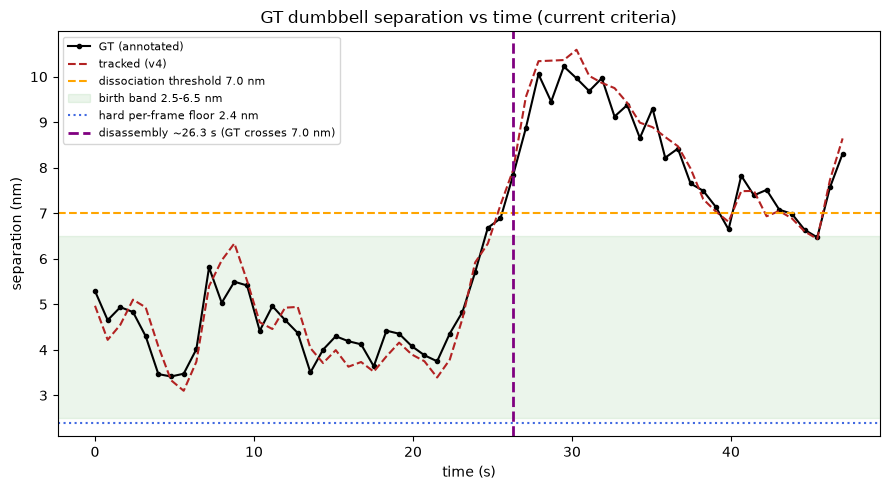

In [18]:
# ============================================================
#  GROUND-TRUTH VALIDATION  (crop space) — corrected to the CURRENT criteria
#  Re-tracks the annotated dumbbell and gates BOTH the annotation and the tracked
#  version by the same physical definition used on the full frame (Step 9):
#     birth 2.5-6.5 nm | death sep>=7.0 nm | bonded>=6 fr |
#     mean_sep in [2.5,6.5] nm | HARD per-frame floor sep>=2.4 nm |
#     mean_vc>=0.50 on TRUE velocity
# ============================================================

# This validation cell needs `tifffile` to read the crop TIFFs (the rest of the notebook
# does not). Install it on demand if it is missing
try:
    import tifffile
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tifffile"])
    import tifffile

import glob, os, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
os.makedirs("Figs", exist_ok=True)

FOLDER = "20250110-1053-PtDum"                   # the denoised display crops (HAADF011..070)
CSV    = "PP_tracks_20250110-1053-PtDum.csv"     # the hand annotation: 2 particles x 60 frames
PXC    = 0.16260                                 # CROP pixel size (nm/px) -- NOT the full-frame 0.45999

# ---- crop-space tracker params: the "v4" tracker, validated to 0.57 nm vs GT ----
#      (kept separate from the full-frame R/RR/MAX_STEP/LAMBDA on purpose)
RC, RRC, STEPC, LAMC = 3, 10, 12, 0.003

# ---- CURRENT physical criteria (mirror Step 9; these VALUES equal the full-frame engine) ----
SEP_DISSOC_NM = 7.0                 # DEATH: first frame with sep >= this      (was 8.5)
BIRTH_MIN, BIRTH_MAX     = 2.5, 6.5 # birth band                               (was 3-8)
MEAN_SEP_MIN, MEAN_SEP_MAX = 2.5, 6.5  # bonded-phase MEAN-sep band            (was <=8, no floor)
MIN_SEP_NM   = 2.4                  # HARD per-frame floor -- NEW              (v8 had none)
MIN_BONDED   = 6                    # permanence (consecutive bonded frames)
VC_MIN       = 0.50                 # co-motion gate, on TRUE velocity         (was 0.80 on position)
# NOTE: the old frac>=0.80 persistence gate is RETIRED (it rejected the GT), so the
#       persistence()/p_shift() permutation machinery is intentionally NOT included here.

# ---------- load the annotation ----------
df  = pd.read_csv(CSV)
DTC = float(np.median(np.diff(sorted(df.t_s.unique()))))   # crop frame time straight from the CSV
def gt_xy(which, unit="nm"):
    d = df[df.particle == which].sort_values("frame")
    return d[["x_nm","y_nm"]].values if unit == "nm" else d[["x","y"]].values
GT1_nm, GT2_nm = gt_xy(1,"nm"), gt_xy(2,"nm")    # annotated centers in nm  (fed to the criteria)
GT1_px, GT2_px = gt_xy(1,"px"), gt_xy(2,"px")    # annotated centers in px  (used to SEED the tracker)

# ---------- crop-space tracker (identical machinery to the full-frame one, crop-tuned) ----------
def gray(im):  return im[...,:3].mean(-1) if im.ndim == 3 else im.astype(float)   # RGB crop -> gray
def hnum(p):   m = re.search(r"HAADF(\d+)\.tif$", os.path.basename(p)); return int(m.group(1)) if m else -1
def euc(a,b):  return float(np.hypot(a[0]-b[0], a[1]-b[1]))
def cap_vec(dx,dy,m):                            # cap a step vector at magnitude m (anti-runaway)
    d = np.hypot(dx,dy)
    if d <= m or d == 0: return dx,dy
    s = m/d; return dx*s, dy*s
def denoise_c(im):                               # crop denoise = min-max + gaussian sigma 2.0 px
    g = gray(im).astype(float); g = (g-g.min())/(np.ptp(g)+1e-9); return gaussian_filter(g, 2.0)

tifs    = sorted(glob.glob(os.path.join(FOLDER,"*HAADF*.tif")), key=hnum)   # HAADF011..070, in order
stack_c = [denoise_c(tifffile.imread(t)) for t in tifs]
FC      = len(stack_c); Hc, Wc = stack_c[0].shape    # crop dims (128x256) -- local as FC/Hc/Wc

def refine_c(clean,cx,cy,r=RC,rr=RRC,lam=LAMC):  # distance-penalized peak pick, then centroid
    x0,x1 = max(0,round(cx-r)), min(Wc,round(cx+r)+1); y0,y1 = max(0,round(cy-r)), min(Hc,round(cy+r)+1)
    if x1 <= x0 or y1 <= y0: return float(np.clip(cx,0,Wc-1)), float(np.clip(cy,0,Hc-1))
    win = clean[y0:y1,x0:x1]; ys,xs = np.mgrid[y0:y1,x0:x1]
    k = np.unravel_index(np.argmax(win - lam*((xs-cx)**2 + (ys-cy)**2)), win.shape)
    px,py = x0+k[1], y0+k[0]
    a0,a1 = max(0,px-rr), min(Wc,px+rr+1); b0,b1 = max(0,py-rr), min(Hc,py+rr+1)
    patch = clean[b0:b1,a0:a1]; w = patch-patch.min()
    if w.sum() <= 0: return float(px), float(py)
    ys2,xs2 = np.mgrid[b0:b1,a0:a1]
    return float((xs2*w).sum()/w.sum()), float((ys2*w).sum()/w.sum())

def track_c(seed1,seed2):                        # follow both particles from frame 0 to the end
    p1 = refine_c(stack_c[0],*seed1); p2 = refine_c(stack_c[0],*seed2); v1=v2=(0.,0.); tr=[(p1,p2)]
    for f in range(1,FC):
        vx1,vy1 = cap_vec(*v1,STEPC); vx2,vy2 = cap_vec(*v2,STEPC)
        n1 = refine_c(stack_c[f], p1[0]+vx1, p1[1]+vy1); n2 = refine_c(stack_c[f], p2[0]+vx2, p2[1]+vy2)
        dx1,dy1 = cap_vec(n1[0]-p1[0], n1[1]-p1[1], STEPC); dx2,dy2 = cap_vec(n2[0]-p2[0], n2[1]-p2[1], STEPC)
        n1=(p1[0]+dx1,p1[1]+dy1); n2=(p2[0]+dx2,p2[1]+dy2); v1=(dx1,dy1); v2=(dx2,dy2); p1,p2=n1,n2
        tr.append((p1,p2))
    a = np.array([t[0] for t in tr])*PXC; b = np.array([t[1] for t in tr])*PXC   # px -> nm
    return a,b
TR1_nm, TR2_nm = track_c(GT1_px[0], GT2_px[0])   # seed the tracker from the GT's frame-0 pixel positions

# ---------- co-motion metric: TRUE velocity correlation (the key fix) ----------
def vel_corr_c(p1,p2):
    # v8 wrote np.diff(p, 0) here -- but 0 is the `n` argument, NOT the axis, so it was a NO-OP
    # and the code correlated raw POSITIONS. Positions are flow-confounded: two particles caught
    # in the same water flow co-drift, so their positions correlate even when unbonded. We
    # difference along axis 0 to get true per-frame VELOCITY (removes the common-mode drift),
    # THEN correlate.
    v1 = np.diff(p1, axis=0); v2 = np.diff(p2, axis=0)
    if len(v1) < 3: return 0.0
    v1c = v1 - v1.mean(0); v2c = v2 - v2.mean(0)
    return float((v1c*v2c).sum() / (np.sqrt((v1c**2).sum()*(v2c**2).sum()) + 1e-9))

# ---------- apply the CURRENT criteria to one separation trace ----------
def analyze(a,b,label):
    sep   = np.hypot(*(a-b).T)                    # center-to-center separation (nm), full trace
    cross = np.where(sep >= SEP_DISSOC_NM)[0]     # death = first crossing of the 7.0 nm threshold
    died  = len(cross) > 0
    death = int(cross[0]) if died else FC
    alive_len = death                             # length of the bonded phase (frames with sep<7)
    ab, bb, sepb = a[:alive_len], b[:alive_len], sep[:alive_len]
    if alive_len >= MIN_BONDED:
        vc    = vel_corr_c(ab,bb)                 # TRUE-velocity co-motion over the bonded phase
        msep  = float(sepb.mean())
        mnsep = float(sepb.min())                 # <-- drives the NEW hard per-frame floor
    else:
        vc, msep, mnsep = 0.0, (float(sepb.mean()) if alive_len else np.nan), np.nan
    # gates, all evaluated on the bonded phase
    birth_ok = BIRTH_MIN <= sep[0] <= BIRTH_MAX
    floor_ok = (alive_len >= MIN_BONDED) and (mnsep >= MIN_SEP_NM)   # NEW: reject if ANY frame dips <2.4
    passes = (birth_ok and alive_len >= MIN_BONDED and
              MEAN_SEP_MIN <= msep <= MEAN_SEP_MAX and floor_ok and vc >= VC_MIN)
    print(f"\n--- {label} ---")
    print(f"  birth sep       = {sep[0]:.2f} nm   (in [{BIRTH_MIN},{BIRTH_MAX}]? {birth_ok})")
    print(f"  bonded lifetime = {alive_len} fr = {alive_len*DTC:.1f} s   "
          f"({'DISSOCIATED @ frame '+str(death)+f' (t={death*DTC:.1f}s)' if died else 'CENSORED (never reached 7 nm)'})")
    print(f"  bonded phase    : mean_sep {msep:.2f} nm | min_sep {mnsep:.2f} nm "
          f"(>= floor {MIN_SEP_NM}? {'OK' if (alive_len>=MIN_BONDED and mnsep>=MIN_SEP_NM) else 'BELOW'})")
    #print(f"  => PASSES CURRENT CRITERIA: {passes}")
    return dict(sep=sep, alive_len=alive_len, died=died, death=death,
                lifetime_s=alive_len*DTC, mean_sep=msep, min_sep=mnsep, vc=vc, passes=passes)

print("="*70)
print("GROUND-TRUTH DUMBBELL under the CURRENT bonded-lifetime criteria")
print(f"(crop frame time from CSV: {DTC:.4f} s | {FC} frames | crop px {PXC} nm)")
print("="*70)
gt_res = analyze(GT1_nm, GT2_nm, "GROUND TRUTH (hand annotation)")
tr_res = analyze(TR1_nm, TR2_nm, "TRACKED (crop v4 pipeline)")

# INTERPRETATION (from the project notes): the tracker reproduces the annotation to ~0.57 nm, so the
# two separation traces should sit almost on top of each other. Note that the GT is known to pull in
# tight at its closest approach and may read BELOW the 2.4 nm hard floor -- this is a *documented
# tension*, not a bug in this cell: either that dip is a tracker merge (root-cause fix = mutual
# exclusion in the tracker) or 2.4 nm is slightly high for true Pt-NP contact. See PDT_project_state
# v9 s10. Do NOT "fix" it by loosening the floor here -- the floor is what removes sep~0 merge artifacts.

# ---------- separation vs time, with the updated markers ----------
tt = np.arange(FC)*DTC
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(tt, gt_res['sep'], '-o', ms=3, color='k',        label='GT (annotated)')
ax.plot(tt, tr_res['sep'], '--',      color='firebrick', label='tracked (v4)')
ax.axhline(SEP_DISSOC_NM, ls='--', color='orange', lw=1.5, label=f'dissociation threshold {SEP_DISSOC_NM} nm')
ax.axhspan(BIRTH_MIN, BIRTH_MAX, color='green', alpha=0.08, label=f'birth band {BIRTH_MIN}-{BIRTH_MAX} nm')
ax.axhline(MIN_SEP_NM, ls=':', color='royalblue', lw=1.5, label=f'hard per-frame floor {MIN_SEP_NM} nm')  # NEW
if gt_res['died']:
    ax.axvline(gt_res['death']*DTC, ls='--', color='purple', lw=2,
               label=f"disassembly ~{gt_res['death']*DTC:.1f} s (GT crosses {SEP_DISSOC_NM} nm)")
ax.set_xlabel('time (s)'); ax.set_ylabel('separation (nm)')
ax.set_title('GT dumbbell separation vs time (current criteria)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig("Figs_mod4/GT_separation_vs_time.png", dpi=600, bbox_inches="tight")
plt.show()

## 4. Ingest the raw frames

The `.emd` is an HDF5 file; the HAADF image stack sits at `EMD_DS`. Velox stores the frame axis
last, so we transpose to `(frames, height, width)`.

In [19]:
with h5py.File(EMD,"r") as f:
    raw = np.transpose(f[EMD_DS][()],(2,0,1)).astype(np.float32)
F_,Hh,Ww = raw.shape
print(f"[{TAGNAME}] loaded raw stack: {F_} frames of {Hh}x{Ww}  (uint16 -> float32)")

[1053] loaded raw stack: 72 frames of 1024x1024  (uint16 -> float32)


## 5. Denoise: percentile clip + Gaussian

**Why percentile clipping, not min-max?** The specimen brightens ~2.4× over the movie (liquid
thinning / dose). Per-frame **min-max** normalisation lets that drift change what a fixed
`threshold` means frame to frame, making the detector **non-stationary** — the population curve
then partly tracks the detector, not the chemistry. Clipping to fixed percentiles (p1–p99.9)
removes that drift.

The Gaussian (`GSIG_NM = 0.40 nm`) is a light blur that suppresses high-frequency water-scatter
noise while leaving the ~2.4 nm particles intact. Classical single-frame denoisers (NL-means,
wavelet, TV) were tested and found *actively harmful* here — they inject spurious peaks and break
tracking within a few frames.

In [6]:
def norm01(a):
    """p1-p99.9 percentile clip. Replaces min-max, which let a drifting intensity
    range change what `threshold` meant on every frame (see markdown above)."""
    a = a.astype(np.float32)
    lo, hi = np.percentile(a, NORM_LO), np.percentile(a, NORM_HI)
    return np.clip((a - lo) / (hi - lo + 1e-9), 0, 1)

print(f"[{TAGNAME}] denoising {F_} frames  (norm p{NORM_LO}-p{NORM_HI}, sigma {GSIG_NM} nm = {GSIG:.3f} px)...")
stack = np.stack([gaussian_filter(norm01(fr), GSIG) for fr in raw])
print("  done. stack shape:", stack.shape)

[1053] denoising 72 frames  (norm p1.0-p99.9, sigma 0.4 nm = 0.870 px)...
  done. stack shape: (72, 1024, 1024)


## 6. Detection & localization primitives

- `detect` — Laplacian-of-Gaussian blob detection (`blob_log`) returns candidate particle centers
  on a frame.
- `refine` — sub-pixel localization: from a predicted center, pick the brightest nearby peak with a
  distance penalty (`argmax(brightness − λ·dist²)`), then take an intensity-weighted centroid in a
  window. This is the step validated to **0.57 nm** localization error against the hand annotation.
- `euc`, `cap_vec` — Euclidean distance and a per-frame displacement cap.

In [7]:
def euc(a,b): return float(np.hypot(a[0]-b[0],a[1]-b[1]))

def cap_vec(dx,dy,m):
    d=np.hypot(dx,dy)
    if d<=m or d==0: return dx,dy
    s=m/d; return dx*s,dy*s

def refine(clean,cx,cy,r=R,rr=RR,lam=LAMBDA):     # intensity-weighted centroid
    x0,x1=max(0,round(cx-r)),min(Ww,round(cx+r)+1); y0,y1=max(0,round(cy-r)),min(Hh,round(cy+r)+1)
    if x1<=x0 or y1<=y0: return float(np.clip(cx,0,Ww-1)),float(np.clip(cy,0,Hh-1))
    win=clean[y0:y1,x0:x1]; ys,xs=np.mgrid[y0:y1,x0:x1]
    k=np.unravel_index(np.argmax(win-lam*((xs-cx)**2+(ys-cy)**2)),win.shape)
    px,py=x0+k[1],y0+k[0]
    a0,a1=max(0,px-rr),min(Ww,px+rr+1); b0,b1=max(0,py-rr),min(Hh,py+rr+1)
    patch=clean[b0:b1,a0:a1]; w=patch-patch.min()
    if w.sum()<=0: return float(px),float(py)
    ys2,xs2=np.mgrid[b0:b1,a0:a1]
    return float((xs2*w).sum()/w.sum()),float((ys2*w).sum()/w.sum())

def detect(fr): return [(float(x),float(y)) for y,x,s in blob_log(fr,**BLOB)]

print("detection primitives defined")

detection primitives defined


### Sanity check — stop here if detection is wrong

Cheap check on frame 0 *before* committing to a long tracking run. A count in the low hundreds is
expected here. If it's `<100` or `>3000`, the detector is misconfigured. Fix `GSIG` / `THRESHOLD`
/ `norm01` before continuing.

In [8]:
_n0 = len(detect(stack[0]))
print(f"  frame 0 detections: {_n0}")
print("  (grid measured 812 with a WIDER blob range (max_sigma=12*SCALE) than the engine")
print("   uses (6*SCALE), so a somewhat lower number here is expected. If this is <100 or")
print("   >3000, re-check GSIG / THRESHOLD / norm01 before letting the run continue.)")

  frame 0 detections: 963
  (grid measured 812 with a WIDER blob range (max_sigma=12*SCALE) than the engine
   uses (6*SCALE), so a somewhat lower number here is expected. If this is <100 or
   >3000, re-check GSIG / THRESHOLD / norm01 before letting the run continue.)


## 7. Track a bonded pair through time

Given a candidate pair at a birth frame, propagate both particles forward with constant-velocity
prediction and a displacement cap, refining each independently every frame. Tracking continues
**only while the pair is bonded**; **death** is the first frame where the center-to-center
separation reaches `SEP_DISSOC_NM = 7 nm`. Pairs that never separate receive`died = False`.

> *Known limitation:* the two particles are localized independently with no mutual exclusion, so on
> a noisy frame both trackers can occasionally land on the same blob (separation → 0). That's why
> the per-frame floor in the next-but-one cell is a hard gate rather than a soft preference.

In [20]:
def track_bonded(f0,p1,p2):
    """track from birth until sep>=SEP_DISSOC (death) or end. Returns traj + alive_len + died."""
    p1=refine(stack[f0],*p1); p2=refine(stack[f0],*p2); v1=v2=(0.,0.)
    A=[p1]; B=[p2]; died=False
    for f in range(f0+1,F_):
        vx1,vy1=cap_vec(*v1,MAX_STEP); vx2,vy2=cap_vec(*v2,MAX_STEP)
        n1=refine(stack[f],p1[0]+vx1,p1[1]+vy1); n2=refine(stack[f],p2[0]+vx2,p2[1]+vy2)
        dx1,dy1=cap_vec(n1[0]-p1[0],n1[1]-p1[1],MAX_STEP); dx2,dy2=cap_vec(n2[0]-p2[0],n2[1]-p2[1],MAX_STEP)
        n1=(p1[0]+dx1,p1[1]+dy1); n2=(p2[0]+dx2,p2[1]+dy2); v1=(dx1,dy1); v2=(dx2,dy2); p1,p2=n1,n2
        A.append(n1); B.append(n2)
        if euc(n1,n2)*PX_NM >= SEP_DISSOC_NM:      # DEATH
            died=True; break
    a=np.array(A); b=np.array(B)
    alive_len = len(a)-1 if died else len(a)       # frames with sep<7 (bonded phase)
    return a, b, alive_len, died

print("track_bonded defined")

track_bonded defined


## 8. Co-motion metric — true-velocity correlation

A real dumbbell's two particles move *together*. But two unrelated particles caught in the same
water flow also **co-drift**, so raw **position** correlation can high for any nearby
pair. Differencing positions into **velocities** removes the common-mode drift, and velocity
correlation cleanly separates genuine bonds from flow-mates.

- `vel_corr` — the correlation used by the accept gate.
- `p_shift` — a circular-shift permutation null (one particle's velocity series is rolled) that
  yields a p-value; used only by the (vestigial) FDR pass later.

In [21]:
def _vel(p): return p if not USE_TRUE_VELOCITY else np.diff(p,axis=0)

def vel_corr(p1,p2):
    # NOTE: np.diff(x,0) is a NO-OP (0 is `n`, not `axis`). The real differencing happens
    # in _vel. This composition is correct but fragile - do not "simplify" it.
    v1=np.diff(_vel(p1),0); v2=np.diff(_vel(p2),0)
    if len(v1)<3: return 0.0
    v1c=v1-v1.mean(0); v2c=v2-v2.mean(0)
    return float((v1c*v2c).sum()/(np.sqrt((v1c**2).sum()*(v2c**2).sum())+1e-9))

def p_shift(p1,p2,nperm=NPERM):
    q1=_vel(p1); q2=_vel(p2)
    v1=np.diff(q1,0); v2=np.diff(q2,0)
    if len(v1)<4: return 1.0
    obs=vel_corr(p1,p2); v1c=v1-v1.mean(0); pref=np.sqrt((v1c**2).sum()); nu=np.empty(nperm)
    for i in range(nperm):
        v2s=np.roll(v2,rng.integers(1,len(v2)-1),axis=0); v2c=v2s-v2s.mean(0)
        nu[i]=(v1c*v2c).sum()/(pref*np.sqrt((v2c**2).sum())+1e-9)
    return (np.sum(nu>=obs)+1)/(nperm+1)

print("velocity-correlation metrics defined")

velocity-correlation metrics defined


## 9. Impose the physical dumbbell criteria

A tracked pair is accepted as a dumbbell only if its **bonded phase** satisfies all of:

- **Permanence** — bonded for at least `MIN_BONDED = 6` frames.
- **Tightness (mean)** — mean separation within `[2.5, 6.5]` nm.
- **Hard per-frame floor** — separation never dips below `2.4 nm` on *any* frame.
- **Co-motion** — whole-bond true-velocity correlation `≥ 0.50`.

In [22]:
def evaluate_bonded(a,b,alive_len):
    # permanence + tightness + per-frame floor + whole-bond velocity co-motion.
    if alive_len < MIN_BONDED: return None                       # permanence
    ab, bb = a[:alive_len], b[:alive_len]
    sep=np.hypot(*(ab-bb).T)*PX_NM; mean_sep=float(sep.mean())
    if not (MEAN_SEP_MIN<=mean_sep<=MEAN_SEP_MAX): return None    # tightness (mean)
    if sep.min() < MIN_SEP_NM: return None                        # HARD per-frame floor
    vc=vel_corr(ab,bb)
    return dict(mean_sep=mean_sep, max_sep=float(sep.max()), min_sep=float(sep.min()),
                mean_vc=vc, passes=(vc>=VC_MIN))

print("evaluate_bonded defined")

evaluate_bonded defined


## 10. Discover dumbbells across the whole movie

For every seed frame: detect particles, find **mutual-nearest-neighbour** pairs whose separation
falls in the birth band, track each to death, and accept those passing the criteria.

**Occupancy bookkeeping** (`claimed_at`) prevents double-counting: a pair's particles are "claimed"
only *while that dumbbell is alive*. At death they're **released**, so the same particle can seed a
new dumbbell later. This is actually how **partner-exchange / re-assembly** events get counted.

In [12]:
accepted=[]; all_tracked=[]
def claimed_at(pt, frame):
    for T in all_tracked:
        idx=frame-T['seed']
        if 0<=idx<T['alive_len']:                    # only while the dumbbell is ALIVE
            if euc(pt,T['a'][idx])<MATCH_TOL or euc(pt,T['b'][idx])<MATCH_TOL: return True
    return False

seed_frames=range(0, F_-MIN_BONDED)
n_new=[]; n_claimed=[]
for k in seed_frames:
    pts=detect(stack[k]); n=len(pts)
    if n<2: n_new.append(0); n_claimed.append(0); continue
    P=np.array(pts)                                  # vectorised distance matrix
    Dm=np.hypot(P[:,None,0]-P[None,:,0], P[:,None,1]-P[None,:,1])
    np.fill_diagonal(Dm, np.inf)
    nn=Dm.argmin(1)
    cidx=[(i,nn[i]) for i in range(n) if nn[nn[i]]==i and i<nn[i] and SEP_MIN<=Dm[i,nn[i]]<=SEP_MAX]
    nnew=ncl=0
    for (i,j) in cidx:
        pa,pb=np.array(pts[i]),np.array(pts[j])
        if claimed_at(pa,k) and claimed_at(pb,k):    # both already in an ALIVE dumbbell
            ncl+=1; continue
        a,b,alive_len,died = track_bonded(k,pa,pb)
        all_tracked.append(dict(seed=k,a=a,b=b,alive_len=alive_len)); nnew+=1
        m=evaluate_bonded(a,b,alive_len)
        if m and m['passes']:
            accepted.append(dict(seed=k, pair=(i,j), a=a, b=b, alive_len=alive_len,
                died=died, death_frame=k+alive_len if died else None,
                lifetime_frames=alive_len, lifetime_s=alive_len*DT, **m))
    n_new.append(nnew); n_claimed.append(ncl)
    if k%10==0: print(f"  frame {k:2d}: {n} blobs, {len(cidx)} pairs, {nnew} new, {ncl} claimed  (accepted {len(accepted)})")

print(f"\n[{TAGNAME}] discovery done: {len(accepted)} accepted dumbbells")

  frame  0: 963 blobs, 268 pairs, 268 new, 0 claimed  (accepted 10)
  frame 10: 426 blobs, 51 pairs, 47 new, 4 claimed  (accepted 27)
  frame 20: 446 blobs, 48 pairs, 39 new, 9 claimed  (accepted 41)
  frame 30: 646 blobs, 105 pairs, 87 new, 18 claimed  (accepted 60)
  frame 40: 746 blobs, 119 pairs, 103 new, 16 claimed  (accepted 96)
  frame 50: 811 blobs, 126 pairs, 102 new, 24 claimed  (accepted 143)
  frame 60: 944 blobs, 152 pairs, 128 new, 24 claimed  (accepted 202)

[1053] discovery done: 243 accepted dumbbells


## 11. FDR pass

A Benjamini–Hochberg FDR is run on each dumbbell's circular-shift p-value, producing a `confirmed`
flag. **This is redundant by construction**: the FDR uses the *same* circular-shift null that the
accept gate is already built on, so it can barely remove anything. It's kept for provenance only —
**do not present `confirmed` as independent statistical confirmation.**

In [13]:
for c in accepted:
    c['p_bonded'] = p_shift(c['a'][:c['alive_len']], c['b'][:c['alive_len']])

def bh(p,q=FDR_Q):
    p=np.asarray(p,float); m=len(p)
    if m==0: return np.zeros(0,bool)
    o=np.argsort(p); th=q*np.arange(1,m+1)/m; bel=p[o]<=th; msk=np.zeros(m,bool)
    if bel.any(): msk[o[:np.max(np.where(bel)[0])+1]]=True
    return msk

conf=bh([c['p_bonded'] for c in accepted])
for c,s in zip(accepted,conf): c['confirmed']=bool(s)
print(f"[{TAGNAME}] FDR done on {len(accepted)} accepted dumbbells")

[1053] FDR done on 243 accepted dumbbells


## 12. Results table

The headline number is the **median bonded lifetime** of dumbbells observed to dissociate. Report
the **median**, not the mean. We've observed that the median was roughly **6.4 s across three
different detectors**, which suggests high robustness across different detectors and settings.

In [14]:
res=pd.DataFrame([{kk:c[kk] for kk in ['seed','pair','lifetime_frames','lifetime_s','died',
      'mean_sep','min_sep','max_sep','mean_vc']} for c in accepted])
if len(res): res=res.sort_values("lifetime_s",ascending=False).reset_index(drop=True)
nconf=sum(1 for c in accepted if c['confirmed'])
print("\n"+"="*92)
print(f"[{TAGNAME}] DETECTOR: norm p{NORM_LO}-p{NORM_HI} | sigma {GSIG_NM} nm ({GSIG:.3f} px) | threshold {THRESHOLD}")
print(f"PHYSICAL criteria: birth 2.5-6.5nm | death sep>={SEP_DISSOC_NM}nm | bonded>={MIN_BONDED}fr | "
      f"mean_sep in [{MEAN_SEP_MIN},{MEAN_SEP_MAX}]nm | HARD per-frame floor sep>={MIN_SEP_NM}nm | "
      f"mean_vc>={VC_MIN} ({'TRUE-velocity' if USE_TRUE_VELOCITY else 'position'})")
print(f"ACCEPTED  (without FDR): {len(res)}   (seed0: {(res.seed==0).sum() if len(res) else 0}, "
      f"later: {(res.seed>0).sum() if len(res) else 0})")
print(f"CONFIRMED (with BH-FDR<{FDR_Q} on circular-shift p): {nconf}")
print("  NOTE: the FDR runs on the SAME circular-shift null the accept gate uses, so it is")
print("        redundant by construction. Do NOT report it as independent confirmation.")
med_s = mean_s = float('nan')
if len(res):
    print(f"  observed dissociation (died): {res.died.sum()}   censored: {(~res.died).sum()}")
    d=res[res.died]
    if len(d):
        mean_s = float(d.lifetime_s.mean()); med_s = float(d.lifetime_s.median())
        print(f"  lifetime accepted (died only): mean {mean_s:.1f}s  median {med_s:.1f}s")
        print(f"  REPORT THE MEDIAN - detector-independent (6.4 s across three detectors). The")
        print(f"  mean moves because the distribution is left-truncated at MIN_BONDED*DT = "
              f"{MIN_BONDED*DT:.2f}s and right-censored ({(~res.died).sum()}).")
    print("\nTOP 20 by lifetime:")
    print(res.head(20).round(3).to_string(index=False))
print("="*92)


[1053] DETECTOR: norm p1.0-p99.9 | sigma 0.4 nm (0.870 px) | threshold 0.1101
PHYSICAL criteria: birth 2.5-6.5nm | death sep>=7.0nm | bonded>=6fr | mean_sep in [2.5,6.5]nm | HARD per-frame floor sep>=2.4nm | mean_vc>=0.5 (TRUE-velocity)
ACCEPTED  (without FDR): 243   (seed0: 10, later: 233)
CONFIRMED (with BH-FDR<0.05 on circular-shift p): 217
  NOTE: the FDR runs on the SAME circular-shift null the accept gate uses, so it is
        redundant by construction. Do NOT report it as independent confirmation.
  observed dissociation (died): 210   censored: 33
  lifetime accepted (died only): mean 7.4s  median 6.4s
  REPORT THE MEDIAN - detector-independent (6.4 s across three detectors). The
  mean moves because the distribution is left-truncated at MIN_BONDED*DT = 4.78s and right-censored (33).

TOP 20 by lifetime:
 seed       pair  lifetime_frames  lifetime_s  died  mean_sep  min_sep  max_sep  mean_vc
    2 (361, 438)               25      19.918  True     4.716    3.266    6.590    0.7

## 13. Figures — lifetime, births/deaths, live population

Three panels: **(a)** the bonded-lifetime distribution (with mean and median marked), **(b)**
cumulative births vs deaths, **(c)** the live dumbbell population over time.

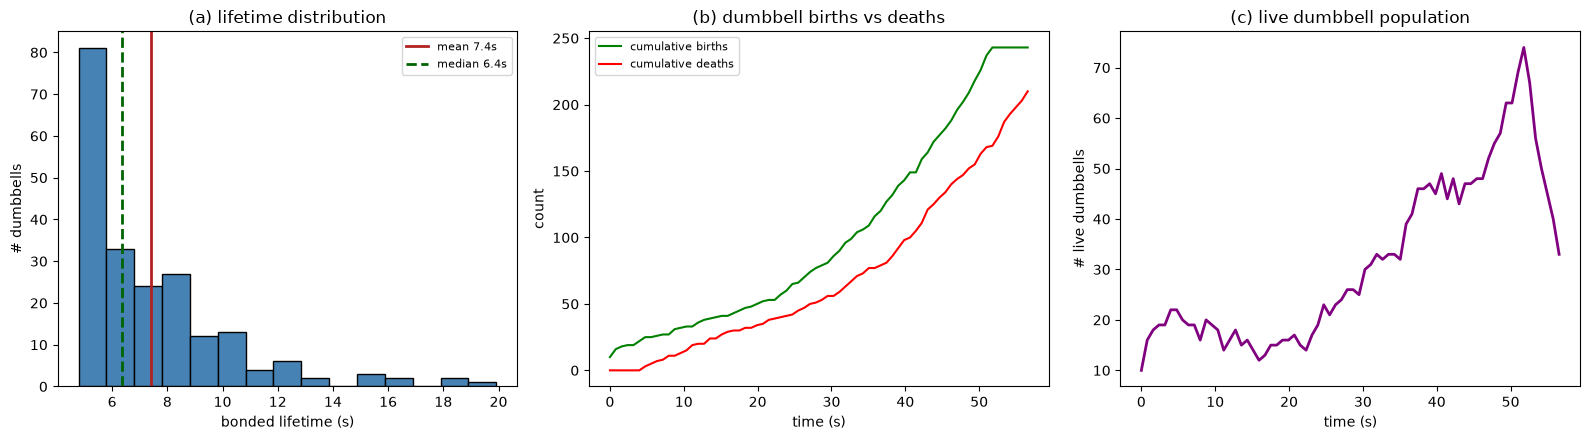

saved -> Figs_mod4/population_dumbbell_dynamics_1053.png
saved -> Figs_mod4/population_curve_1053.npz  (for drift_retest_matched.py)


In [15]:
fig,ax=plt.subplots(1,3,figsize=(16,4.5))
if len(res) and res.died.any():
    ax[0].hist(res[res.died].lifetime_s,bins=15,color='steelblue',edgecolor='k')
    ax[0].axvline(mean_s,color='firebrick',lw=2,label=f'mean {mean_s:.1f}s')
    ax[0].axvline(med_s,color='darkgreen',lw=2,ls='--',label=f'median {med_s:.1f}s')
    ax[0].legend(fontsize=8)
ax[0].set_xlabel('bonded lifetime (s)'); ax[0].set_ylabel('# dumbbells'); ax[0].set_title('(a) lifetime distribution')

births=np.zeros(F_); deaths=np.zeros(F_)
for c in accepted:
    births[c['seed']]+=1
    if c['died'] and c['death_frame'] is not None and c['death_frame']<F_: deaths[c['death_frame']]+=1
tt=np.arange(F_)*DT
ax[1].plot(tt,np.cumsum(births),'-',color='green',label='cumulative births')
ax[1].plot(tt,np.cumsum(deaths),'-',color='red',label='cumulative deaths')
ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('count'); ax[1].set_title('(b) dumbbell births vs deaths'); ax[1].legend(fontsize=8)

live=np.cumsum(births)-np.cumsum(deaths)
np.savez(f"Figs_mod4/population_curve_{TAGNAME}.npz",
         births=births, deaths=deaths, DT=DT, F=F_, MIN_BONDED=MIN_BONDED)
ax[2].plot(tt,live,'-',color='purple',lw=2)
ax[2].set_xlabel('time (s)'); ax[2].set_ylabel('# live dumbbells'); ax[2].set_title('(c) live dumbbell population')
plt.tight_layout()
_png = f"Figs_mod4/population_dumbbell_dynamics_{TAGNAME}.png"
plt.savefig(_png, dpi=300, bbox_inches="tight")
plt.show()
print(f"saved -> {_png}")
print(f"saved -> Figs_mod4/population_curve_{TAGNAME}.npz  (for drift_retest_matched.py)")

## Credits and references

Built with Python **NumPy, SciPy, scikit-image, tifffile, h5py** (and matplotlib).

**Methods & libraries**
- Image analysis via **scikit-image** (van der Walt et al., *PeerJ* 2014) and **SciPy** (Virtanen et al., *Nat. Methods* 2020).
- TIFF/HDF5 I/O via **tifffile** and **h5py**.

**Data**
- Pt STEM image dataset (from the authors).

*Third-party datasets, pretrained models, and libraries are the property of their respective authors and are used here for noncommercial educational purposes. Cite the original sources when you build on this material.*